In [2]:
%load_ext autoreload
%autoreload 2

import os,sys
import torch
import numpy as np
import pandas as pd 

from torch import nn
from torchdiffeq import odeint

from PINN import models
import matplotlib.pyplot as plt

import umap
import phate

from scipy.stats import gaussian_kde

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
import anndata as ad

In [4]:
import scanpy as sc

In [5]:
sc.set_figure_params(figsize=(4,4), dpi=80, frameon=False)

In [1]:
import umap
import phate

# reload synthesized data
convert to adata

In [6]:
syn_init_ckpt = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_init_condition_0-4.ckpt")
cellstate = syn_init_ckpt['cellstate']

In [7]:
syn_result_ckpt = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_result_0-4.ckpt")
density = syn_result_ckpt['u_simulate']
integrate_time = syn_result_ckpt['integrate_time']

In [8]:
syn_ad = sc.read_h5ad("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_cell_0_4.h5ad")

syn_ad.uns['pop'] = {
    't' : np.around(integrate_time.numpy(), decimals=2),
    'mean' : density.numpy().sum(axis=1)

}

sc.pp.neighbors(syn_ad, n_neighbors=5, use_rep='X_data')
sc.tl.leiden(syn_ad, resolution=1)
sc.tl.leiden(syn_ad, resolution=0.1, key_added='leiden_rs0.1')

syn_ad

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/tmp/ipykernel_707894/2416465489.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(syn_ad, resolution=1)


AnnData object with n_obs × n_vars = 22000 × 5
    obs: 'time', 'source', 'timepoint', 'leiden', 'leiden_rs0.1'
    uns: 'leiden', 'leiden_colors', 'leiden_rs0.1', 'leiden_rs0.1_colors', 'neighbors', 'pop'
    obsm: 'Delta_DM', 'X_data', 'X_phate', 'X_umap'
    obsp: 'connectivities', 'distances'

convert to adata

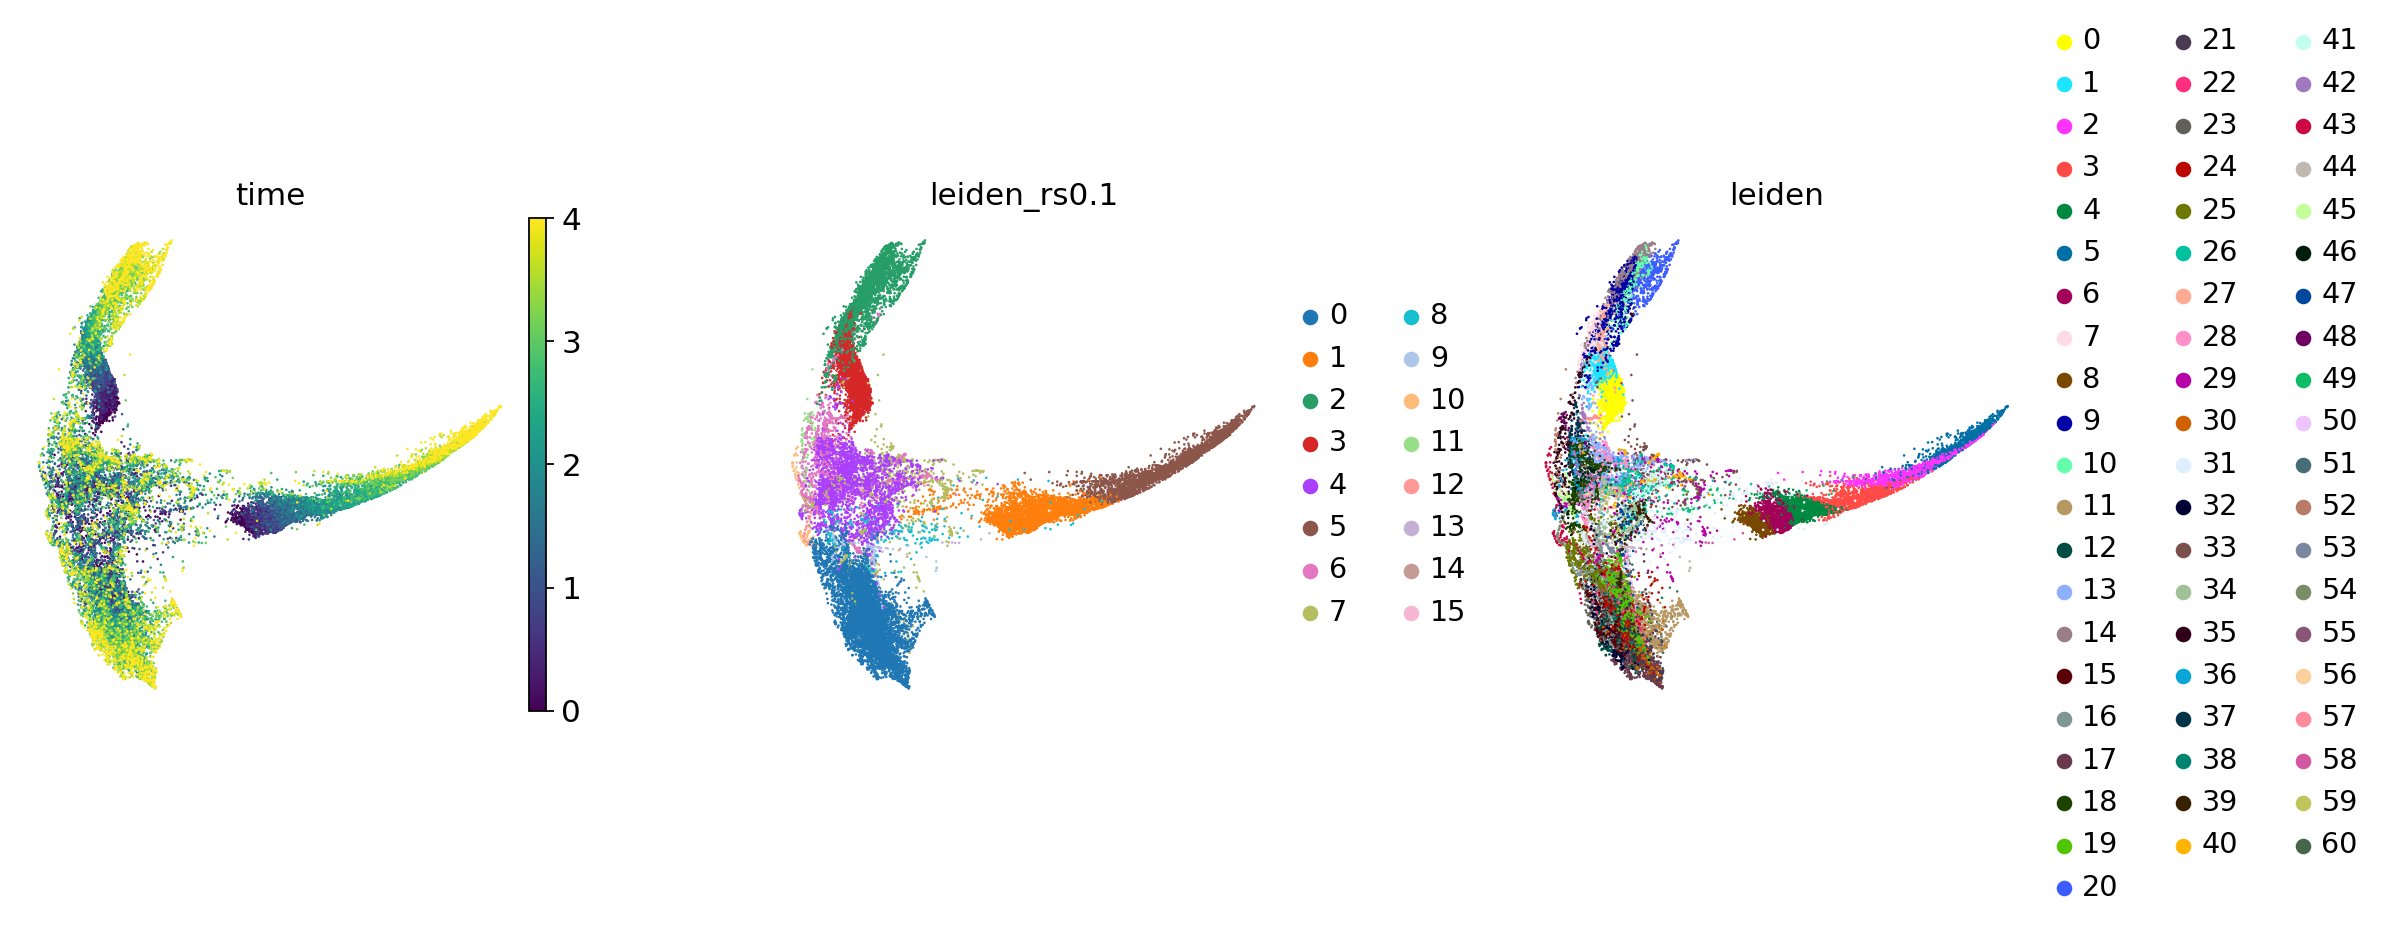

In [25]:
sc.pl.umap(syn_ad,  color=['time', 'leiden_rs0.1', 'leiden'], wspace=0.35)

In [26]:
syn_ad.write_h5ad("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_cell_0_4.h5ad")

# load model

In [9]:
syn_ad = sc.read_h5ad("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_cell_0_4.h5ad")
cellstate = torch.from_numpy(syn_ad.X).float()
syn_ad

AnnData object with n_obs × n_vars = 22000 × 5
    obs: 'time', 'source', 'timepoint', 'leiden', 'leiden_rs0.1'
    uns: 'leiden', 'leiden_colors', 'leiden_rs0.1', 'leiden_rs0.1_colors', 'neighbors', 'pop'
    obsm: 'Delta_DM', 'X_data', 'X_phate', 'X_umap'
    obsp: 'connectivities', 'distances'

In [10]:
non_zero_cell = np.all(density.numpy()!=0, axis=0)

In [11]:
major_cell = syn_ad[non_zero_cell]
major_cellstate = cellstate[non_zero_cell]


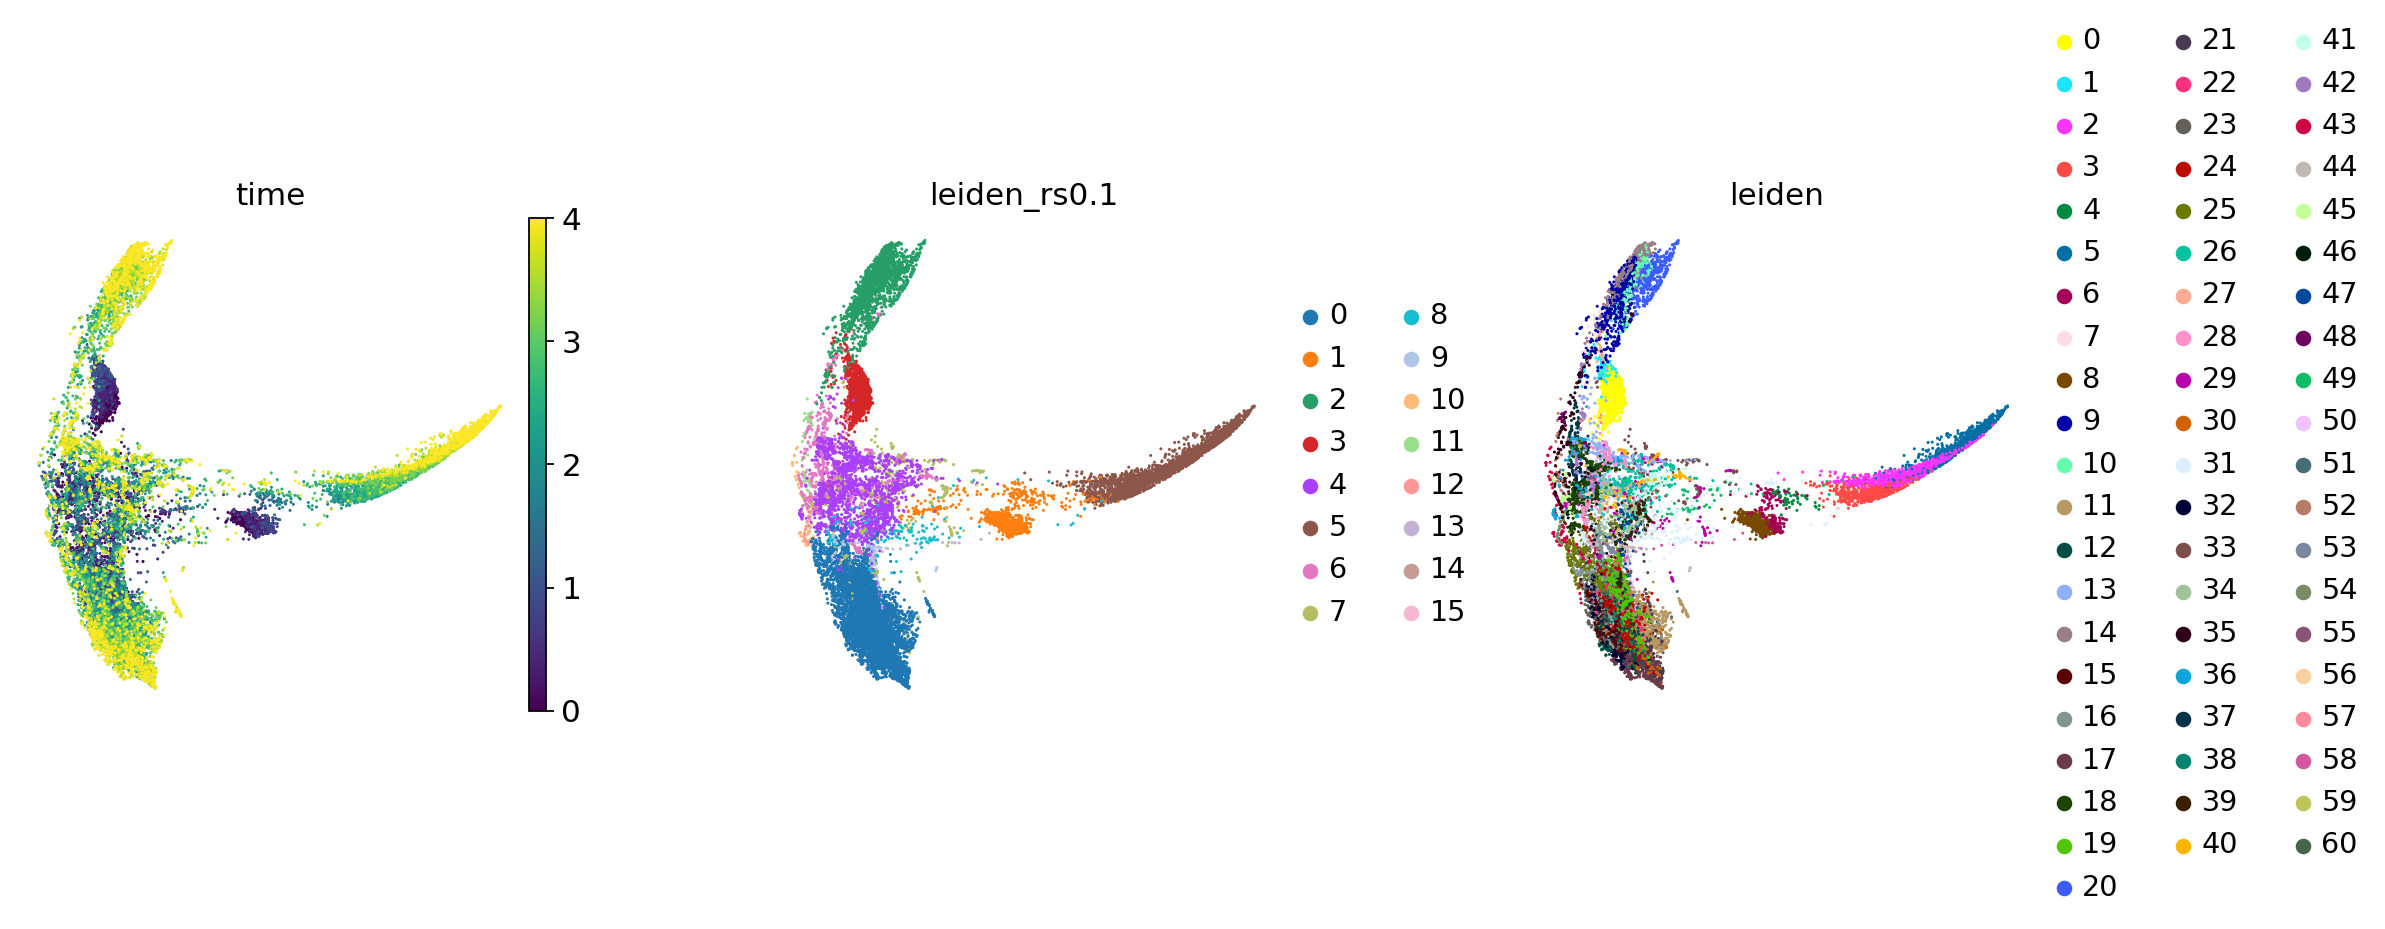

In [12]:
sc.pl.umap(major_cell,  color=['time', 'leiden_rs0.1', 'leiden'], wspace=0.35)

In [13]:
spline_knots = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan23/biomodal_g_norm_D_params_0_4.ckpt")

v_spline = models.MultiDim_CubicSpline(y=spline_knots['v'].T, x=spline_knots['x'].T)
g_spline = models.MultiDim_CubicSpline(y=spline_knots['g'].T, x=spline_knots['x'].T, collapse=True)
D_spline = models.MultiDim_CubicSpline(y=spline_knots['D'].T, x=spline_knots['x'].T, collapse=True)

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))


In [14]:
with torch.no_grad():
    v_true = v_spline(cellstate, None).cpu().numpy()
    g_true = g_spline(cellstate, None).cpu().numpy().flatten()
    D_true = D_spline(cellstate, None).cpu().numpy().flatten()

syn_ad.obs['g_true'] = g_true
syn_ad.obs['D_true'] = D_true
syn_ad.obsm['v_true'] = v_true
syn_ad.layers['v_true'] = v_true

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/Spline_models.py:71: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at ../aten/src/ATen/native/BucketizationUtils.h:32.)
  idxs = torch.searchsorted(self.x[1:], xs)


Jan 21 models    

<font size=1>   

```python
    # v0
    # ckpt_path = "logs/5Dim_ncs_synparam_Jan21/lightning_logs/version_0/checkpoints/epoch=84-total_loss=15.42699528.ckpt"
    # # v1
    # ckpt_path = "logs/5Dim_ncs_synparam_Jan21/lightning_logs/version_1/checkpoints/epoch=194-val_loss=10.35996342.ckpt"

    # # v2
    # ckpt_path = "logs/5Dim_ncs_synparam_Jan21/lightning_logs/version_2/checkpoints/epoch=267-val_loss=4.51624393.ckpt"

    # v3
    # ckpt_path = "logs/5Dim_ncs_synparam_Jan21/lightning_logs/version_3/checkpoints/epoch=264-val_loss=12.97432327.ckpt"

    # # v4
    ckpt_path = "logs/5Dim_ncs_synparam_Jan21/lightning_logs/version_4/checkpoints/epoch=276-val_loss=17.10971832.ckpt"

    # # v5
    # ckpt_path = "logs/5Dim_ncs_synparam_Jan21/lightning_logs/version_5/checkpoints/epoch=134-val_loss=12.29932976.ckpt"
    model = models.pde_params.load_from_checkpoint(ckpt_path)
```
</font>

In [106]:
# v0
# ckpt_path = "logs/5Dim_ncs_synparam_Jan23_0-4/lightning_logs//version_0/checkpoints/epoch=67-val_loss=74.12171936.ckpt"
# # v1
# ckpt_path = "logs/5Dim_ncs_synparam_Jan23_0-4/lightning_logs//version_1/checkpoints/epoch=64-val_loss=119.44229889.ckpt"

# # v2
# ckpt_path = "logs/5Dim_ncs_synparam_Jan23_0-4/lightning_logs//version_2/checkpoints/epoch=53-val_loss=94.77770233.ckpt"

# v3
ckpt_path = "logs/5Dim_ncs_synparam_Jan23_0-4/lightning_logs//version_3/checkpoints/epoch=69-val_loss=111.61859131.ckpt"

# # v4
# ckpt_path = "logs/5Dim_ncs_synparam_Jan23_0-4/lightning_logs/version_4/checkpoints/epoch=87-val_loss=28.82689476.ckpt"

# # v5
# ckpt_path = "logs/5Dim_ncs_synparam_Jan23_0-4/lightning_logs//version_5/checkpoints/epoch=30-val_loss=38.86276627.ckpt"

# # v6
# ckpt_path = "logs/5Dim_ncs_synparam_Jan23_0-4/lightning_logs//version_6/checkpoints/epoch=72-val_loss=92.49285126.ckpt"
# # # v7
# ckpt_path = "logs/5Dim_ncs_synparam_Jan23_0-4/lightning_logs//version_7/checkpoints/epoch=89-val_loss=112.94977570.ckpt"
# # # v8
# ckpt_path = "logs/5Dim_ncs_synparam_Jan23_0-4/lightning_logs//version_8/checkpoints/epoch=75-val_loss=114.61932373.ckpt"
model = models.pde_params.load_from_checkpoint(ckpt_path)

In [107]:
with torch.no_grad():
    g_pred = model.g(cellstate, None).cpu().numpy()
    v_pred = model.v(cellstate, None).cpu().numpy()
    D_pred = model.D(cellstate, None).cpu().numpy()

syn_ad.obs['g_pred'] = g_pred
syn_ad.obs['D_pred'] = D_pred
syn_ad.layers['v_pred'] = v_pred

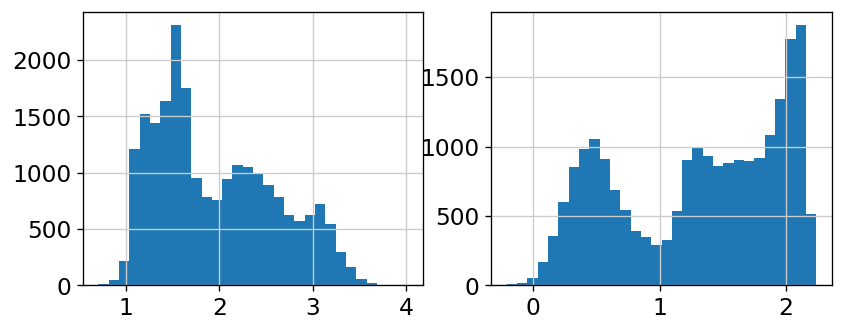

In [108]:
fig, axs = plt.subplots(1,2, figsize=(8,3), dpi=60)
axs[0].hist(syn_ad.obs['g_true'].values, bins=30);
axs[1].hist(syn_ad.obs['g_pred'].values, bins=30);

In [109]:
from scipy.stats import spearmanr, pearsonr

In [110]:
print(g_pred.max(), g_pred.min())
g_true.max(), g_true.min()

2.238043 -0.2094327


(4.015475, 0.7051047)

In [111]:
print(spearmanr(g_pred, g_true))
print(pearsonr(g_pred, g_true))

SignificanceResult(statistic=0.7203917009351567, pvalue=0.0)
PearsonRResult(statistic=0.6982232081040256, pvalue=0.0)


In [112]:
print("\ncorrelation of v : \n")
for i in range(5):
    print('dimension ',i)
    print(spearmanr(v_pred[:,i], v_true[:,i]))
    print(pearsonr(v_pred[:,i], v_true[:,i]))


correlation of v : 

dimension  0
SignificanceResult(statistic=0.8999166652721415, pvalue=0.0)
PearsonRResult(statistic=0.8969072420207677, pvalue=0.0)
dimension  1
SignificanceResult(statistic=0.9135798959585679, pvalue=0.0)
PearsonRResult(statistic=0.8737126691882129, pvalue=0.0)
dimension  2
SignificanceResult(statistic=0.7524342183069348, pvalue=0.0)
PearsonRResult(statistic=0.8667082113339014, pvalue=0.0)
dimension  3
SignificanceResult(statistic=0.9721882411022074, pvalue=0.0)
PearsonRResult(statistic=0.8671470896306401, pvalue=0.0)
dimension  4
SignificanceResult(statistic=0.8213299978211371, pvalue=0.0)
PearsonRResult(statistic=0.7984501670610599, pvalue=0.0)


In [113]:
import seaborn as sns

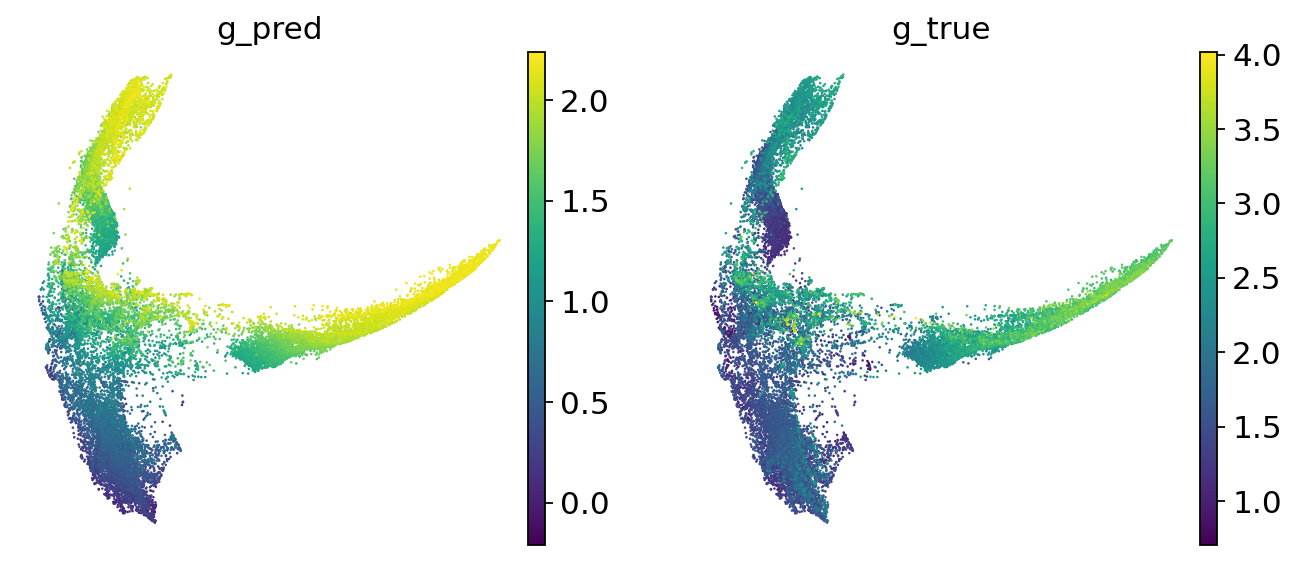

In [114]:
sc.pl.umap(syn_ad, color=['g_pred', 'g_true'])

Text(0, 0.5, 'D')

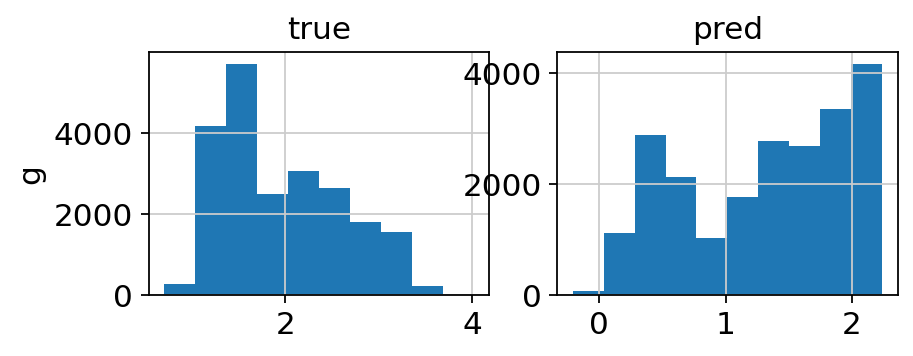

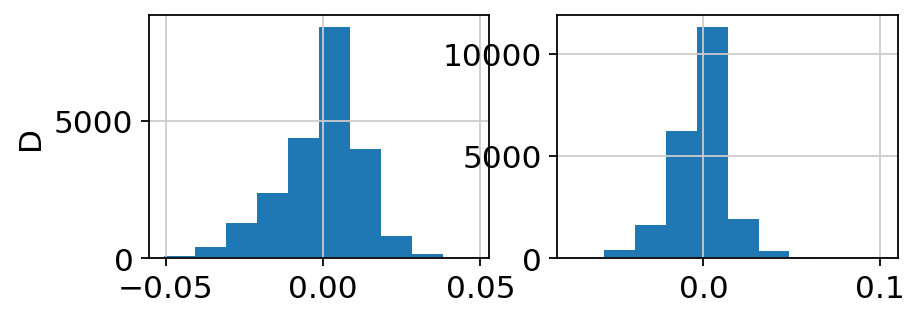

In [115]:
fig, axs = plt.subplots(1,2, figsize=(6,2))
axs[0].hist(g_true)
axs[1].hist(g_pred)
axs[0].set_ylabel('g')
axs[0].set_title('true')
axs[1].set_title('pred')


fig, axs = plt.subplots(1,2, figsize=(6,2))
axs[0].hist(D_true)
axs[1].hist(D_pred)
axs[0].set_ylabel('D')

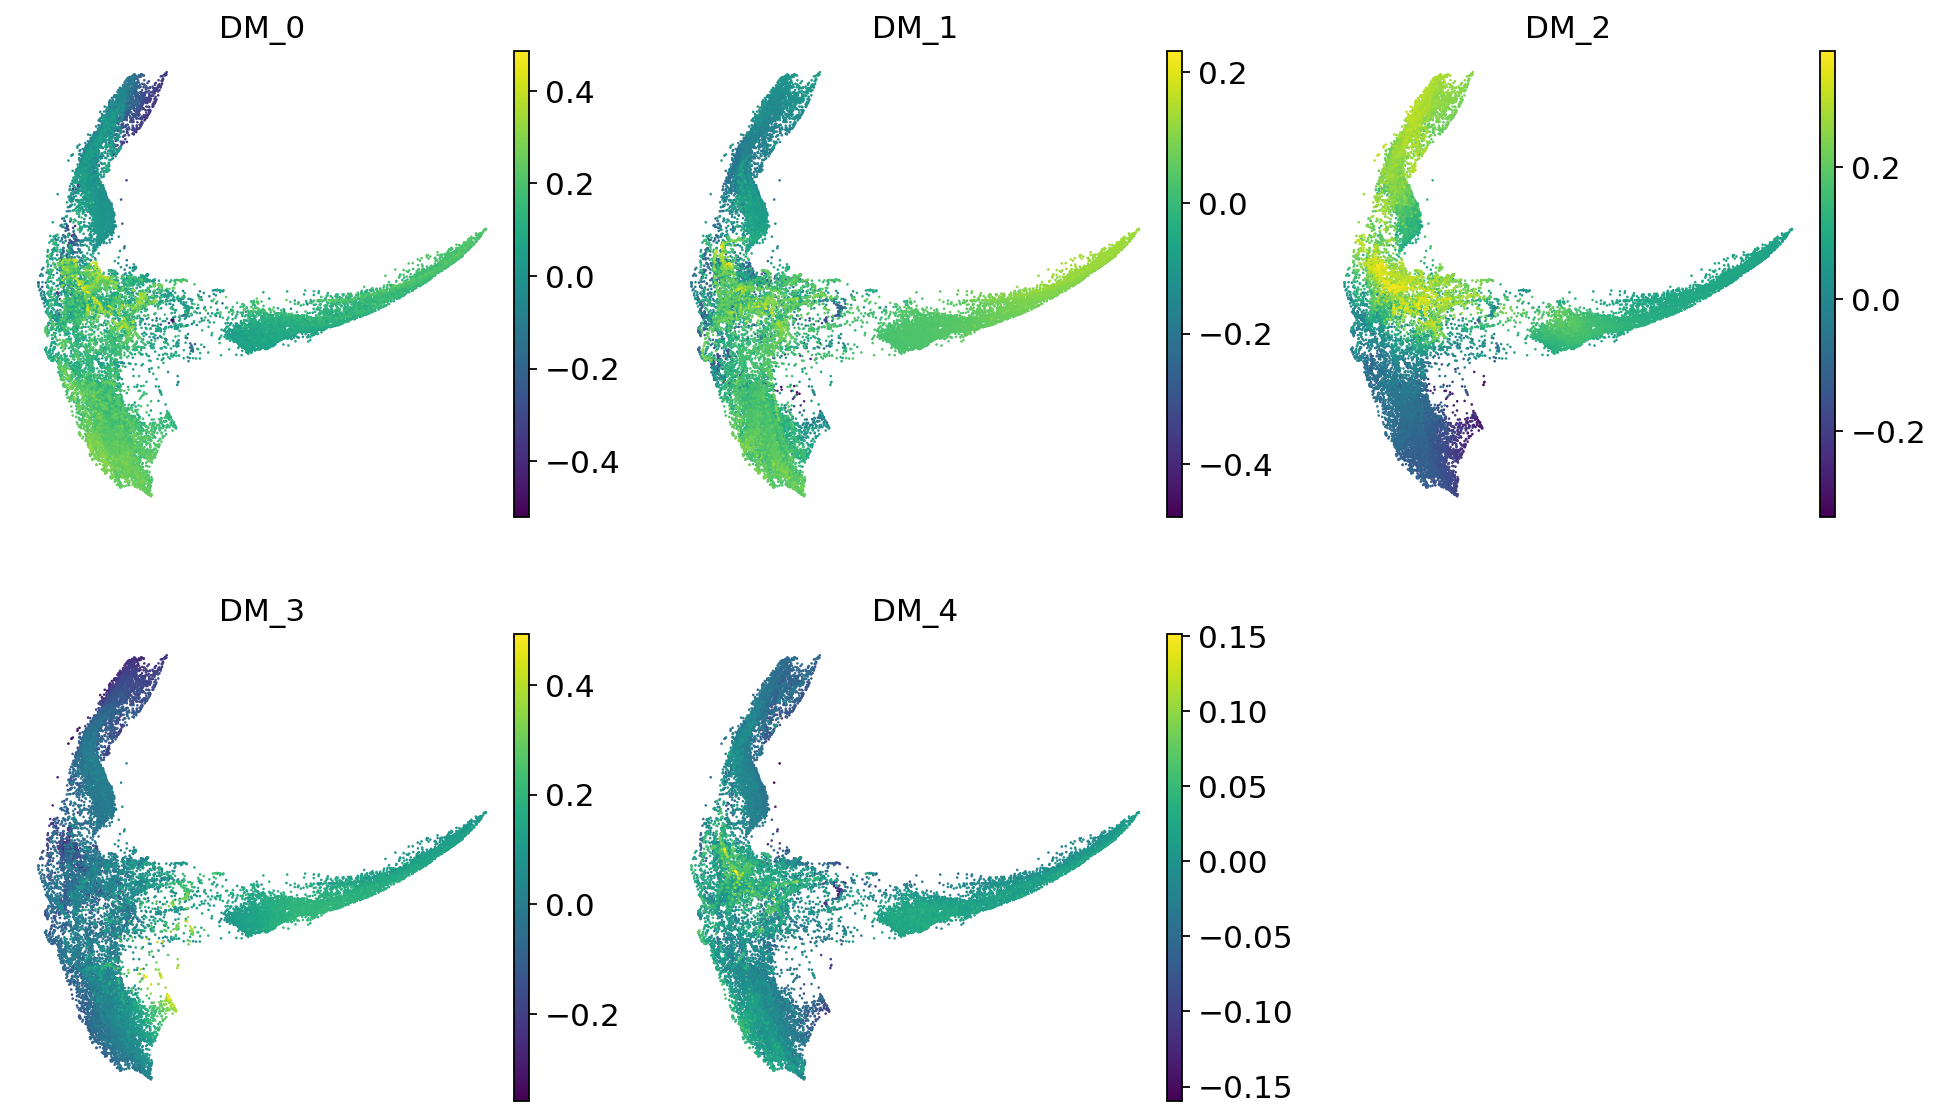

In [116]:
sc.pl.embedding(syn_ad, basis='X_phate', color=['DM_0', 'DM_1','DM_2', 'DM_3','DM_4'], layer='v_pred', ncols=3)

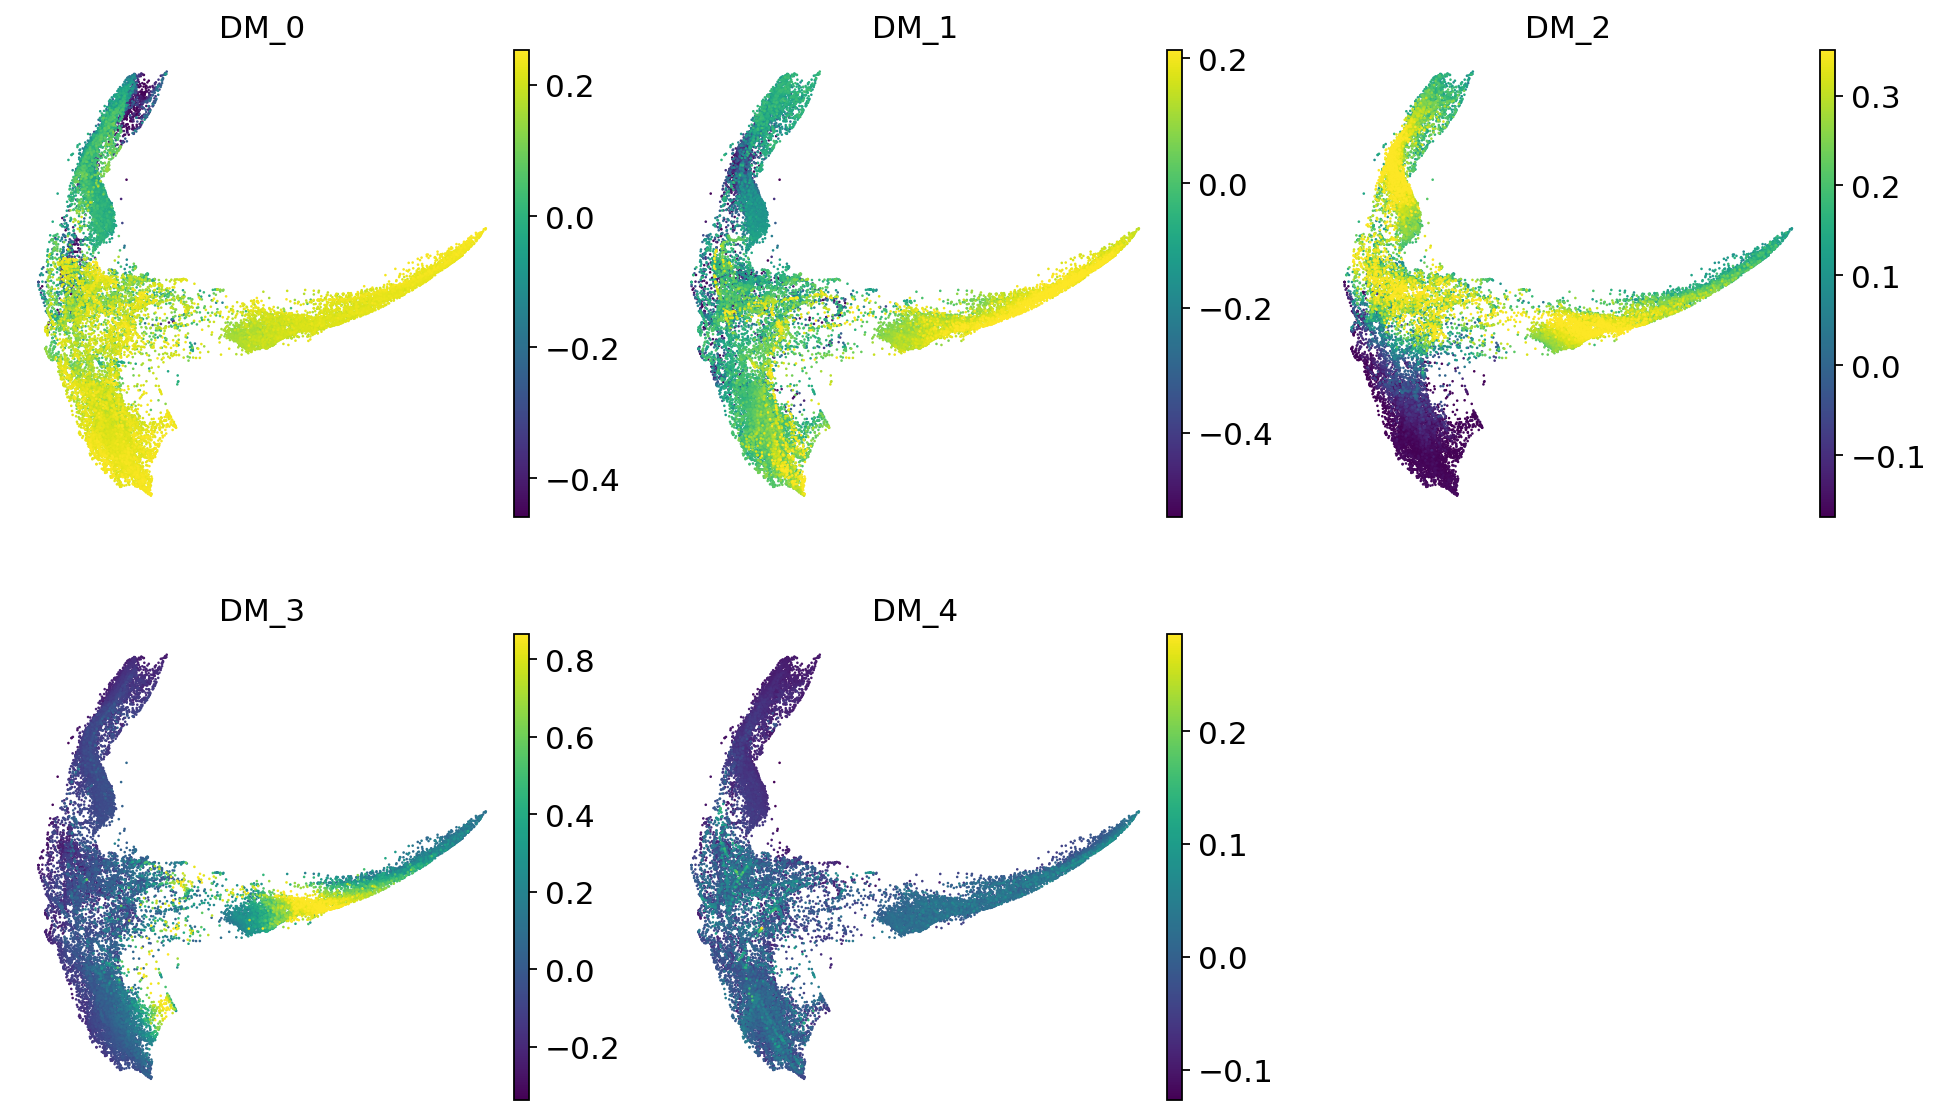

In [117]:
sc.pl.embedding(syn_ad, basis='X_phate', color=['DM_0', 'DM_1','DM_2', 'DM_3','DM_4'], layer='v_true', ncols=3)

In [118]:
obs = syn_ad.obs.copy()

<Axes: xlabel='leiden_rs0.1', ylabel='growth rate'>

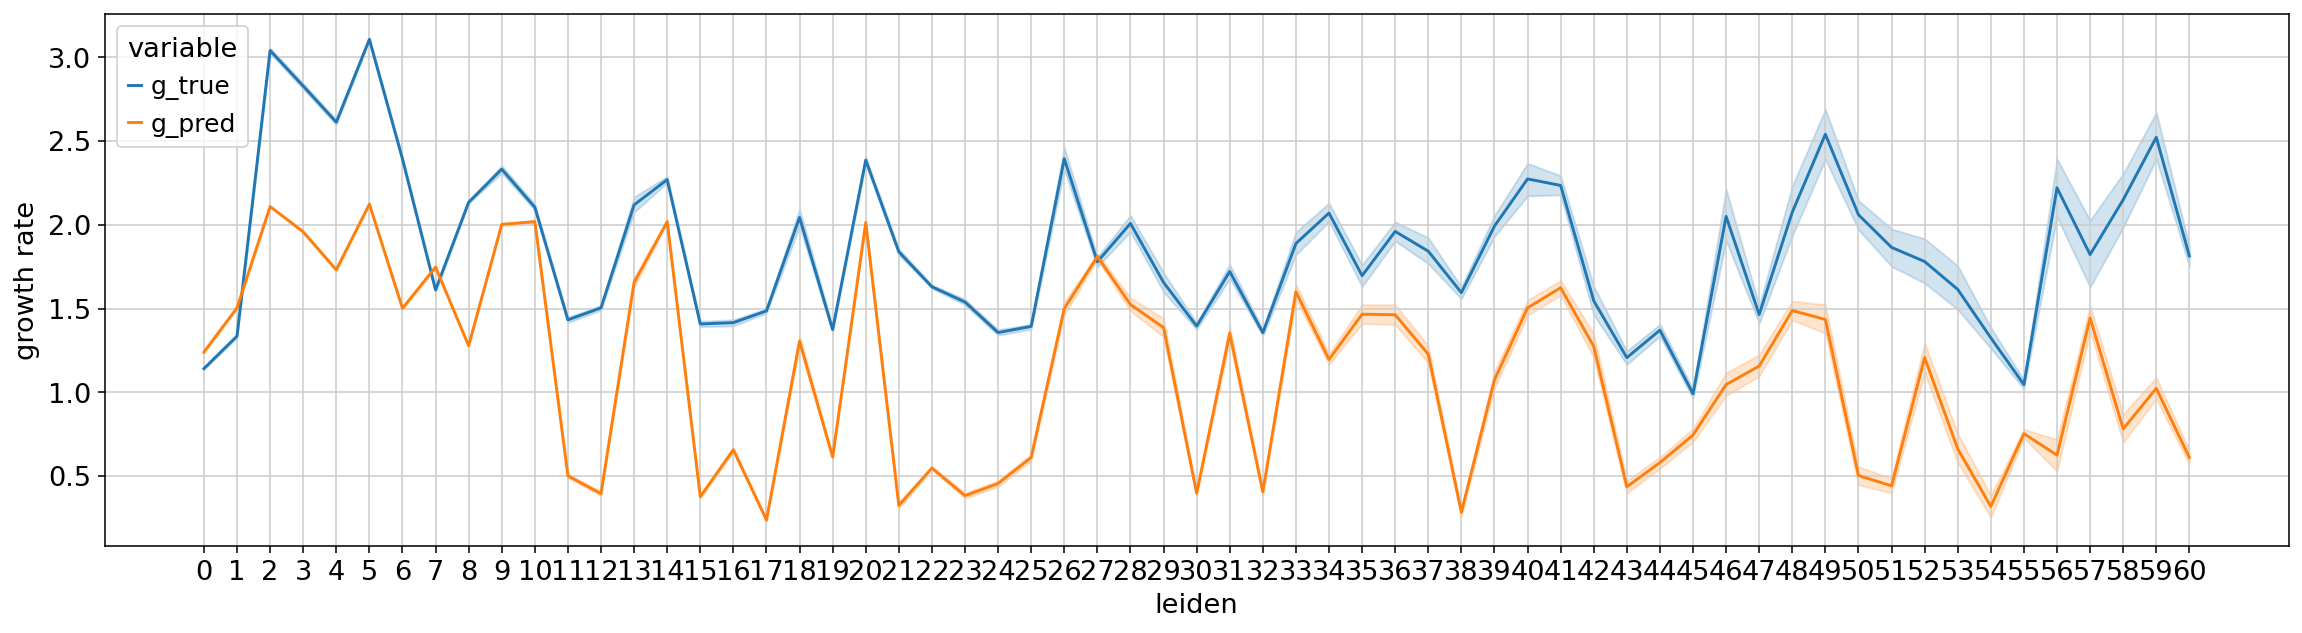

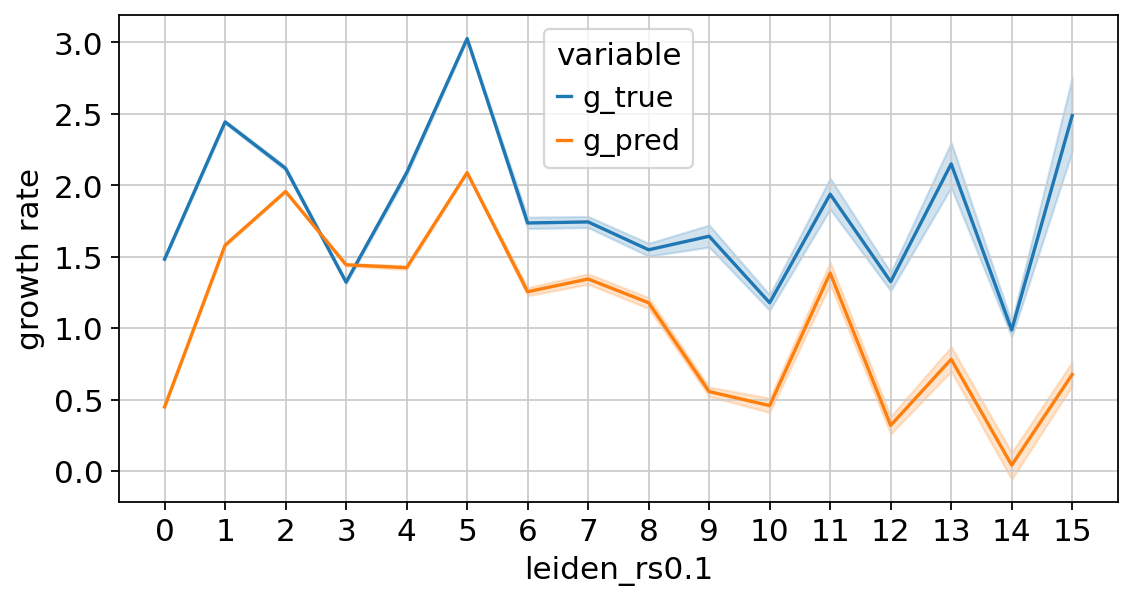

In [119]:
melt = obs[['leiden','g_true','g_pred']].melt(id_vars='leiden', value_name='growth rate')
fig=plt.figure(figsize=(20,5), dpi=70)
sns.lineplot(data=melt, x='leiden', y='growth rate', hue='variable', ax=fig.gca())#, width=0.5)

melt = obs[['leiden_rs0.1','g_true','g_pred']].melt(id_vars='leiden_rs0.1', value_name='growth rate')
fig=plt.figure(figsize=(8,4))
sns.lineplot(data=melt, x='leiden_rs0.1', y='growth rate', hue='variable', ax=fig.gca())#, width=0.5)

<Axes: xlabel='time', ylabel='growth rate'>

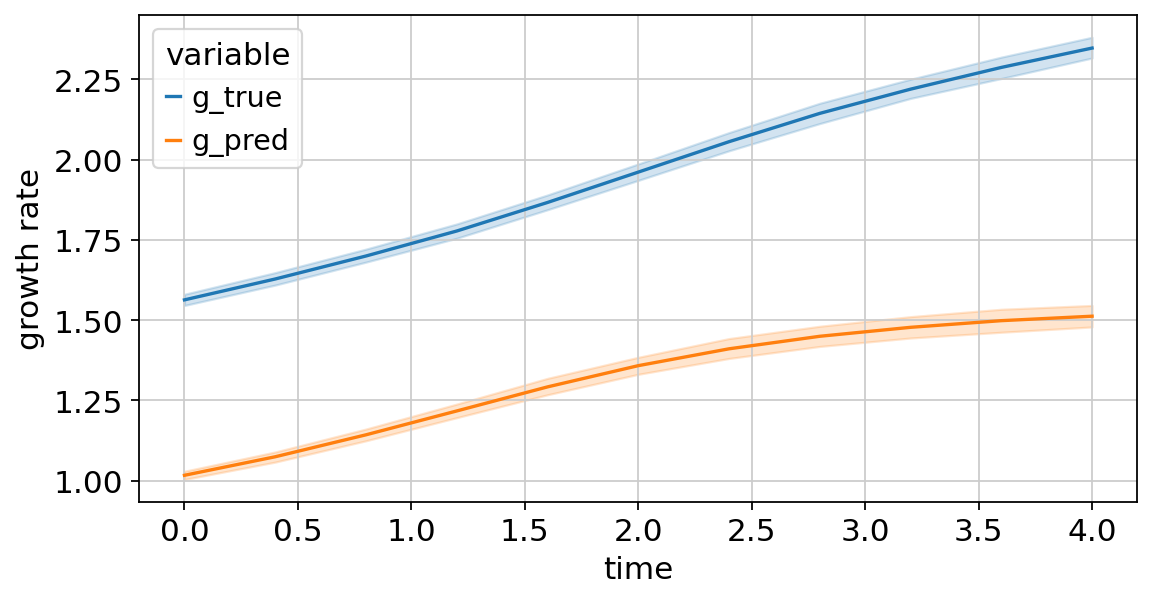

In [120]:
melt = obs[['time','g_true','g_pred']].melt(id_vars='time', value_name='growth rate')
fig=plt.figure(figsize=(8,4))
sns.lineplot(data=melt, x='time', y='growth rate', hue='variable', ax=fig.gca())